# FilingSignal: Results & Charts

This notebook loads the processed data from the pipeline scripts in `src/`
and walks through the key results with charts. Run the scripts in `src/`
first (in order) so the files below exist in `data/processed/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

signal = pd.read_csv("../data/processed/signal_table.csv")
signal["filing_date"] = pd.to_datetime(signal["filing_date"])

# momentum file is produced by run_validation_checks.py
try:
    with_momentum = pd.read_csv("../data/processed/signal_table_with_momentum.csv")
    with_momentum["filing_date"] = pd.to_datetime(with_momentum["filing_date"])
except FileNotFoundError:
    with_momentum = None
    print("signal_table_with_momentum.csv not found -- run run_validation_checks.py first "
          "if you want the momentum-control chart below.")

companies = pd.read_csv("../data/sp500_sample_80.csv")

print(f"Loaded {len(signal)} filing events")
signal.head()


Loaded 610 filing events


,ticker,filing_date,start_date,start_price,return_1m,return_3m,negative_density,positive_density,word_count,negative_density_change,positive_density_change
0,FOX,2025-08-06,2025-08-06,48.987537,0.136428,0.180691,0.009640,0.005441,46681,0.000788,-0.000235
1,FOX,2024-08-08,2024-08-08,35.867340,0.018131,0.163343,0.008852,0.005676,50385,0.001104,-0.000181
2,FOX,2023-08-11,2023-08-11,31.143600,-0.080588,-0.139023,0.007748,0.005857,49173,0.000137,0.000119
3,FOX,2022-08-12,2022-08-12,31.891491,-0.071200,-0.172741,0.007611,0.005738,50190,0.000006,-0.000221
4,FOX,2021-08-10,2021-08-10,31.702929,-0.002732,0.122556,0.007605,0.005959,52859,-0.000191,0.000250


## 1. Does tone shift line up with forward returns?

Sorting all filings into 5 equal-sized groups by the size of their tone
shift, from most-negative to most-positive, and comparing the average
return that followed.


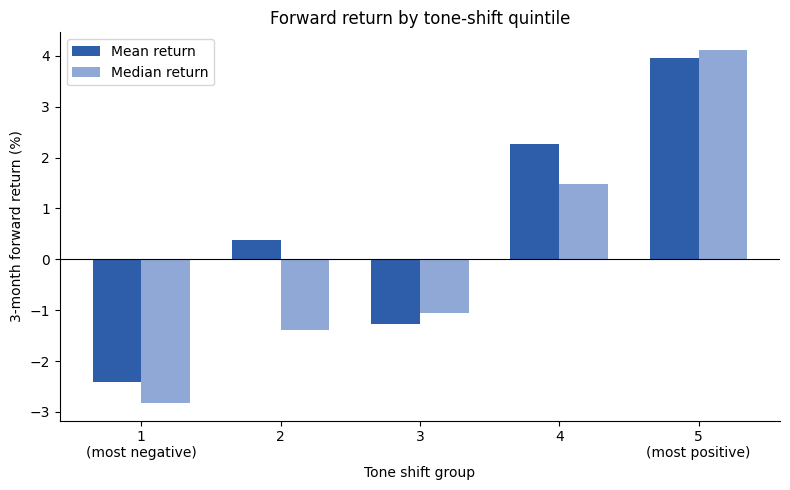

In [2]:
signal["group"] = pd.qcut(
    signal["negative_density_change"], q=5,
    labels=["1\n(most negative)", "2", "3", "4", "5\n(most positive)"],
)

group_stats = signal.groupby("group", observed=True)["return_3m"].agg(["mean", "median"])

fig, ax = plt.subplots()
x = np.arange(len(group_stats))
width = 0.35

ax.bar(x - width/2, group_stats["mean"] * 100, width, label="Mean return", color="#2E5EAA")
ax.bar(x + width/2, group_stats["median"] * 100, width, label="Median return", color="#8FA8D6")

ax.set_xticks(x)
ax.set_xticklabels(group_stats.index)
ax.set_ylabel("3-month forward return (%)")
ax.set_xlabel("Tone shift group")
ax.set_title("Forward return by tone-shift quintile")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


## 2. Overall relationship and statistical significance


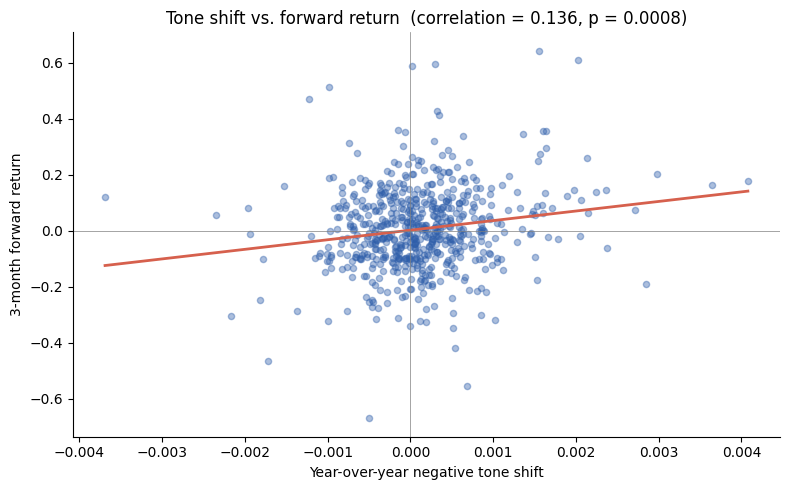

Correlation: 0.136
P-value:     0.0008


In [3]:
corr, p_value = stats.spearmanr(signal["negative_density_change"], signal["return_3m"])

fig, ax = plt.subplots()
ax.scatter(signal["negative_density_change"], signal["return_3m"],
           alpha=0.4, s=20, color="#2E5EAA")

# simple trend line for visual reference
z = np.polyfit(signal["negative_density_change"], signal["return_3m"], 1)
x_line = np.linspace(signal["negative_density_change"].min(), signal["negative_density_change"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="#D6604D", linewidth=2)

ax.set_xlabel("Year-over-year negative tone shift")
ax.set_ylabel("3-month forward return")
ax.set_title(f"Tone shift vs. forward return  (correlation = {corr:.3f}, p = {p_value:.4f})")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"Correlation: {corr:.3f}")
print(f"P-value:     {p_value:.4f}")


## 3. Is this just price momentum in disguise?

Comparing the tone-shift/return correlation before and after removing
the portion explainable by trailing 3-month price momentum.


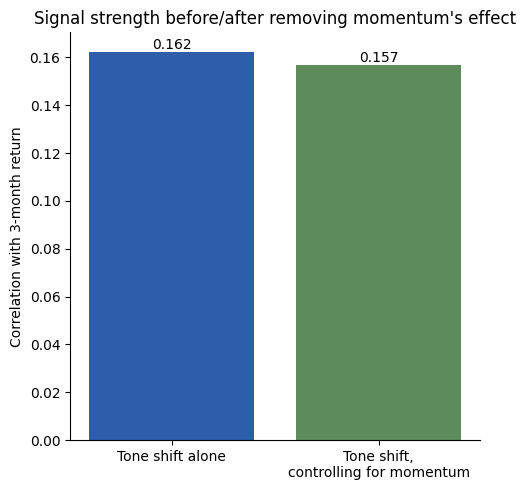

In [4]:
if with_momentum is not None:
    wm = with_momentum.dropna(subset=["momentum_3m", "negative_density_change", "return_3m"])

    raw_corr, _ = stats.spearmanr(wm["negative_density_change"], wm["return_3m"])

    def residualize(y, x):
        x = np.array(x).reshape(-1, 1)
        x = np.hstack([np.ones_like(x), x])
        coeffs, _, _, _ = np.linalg.lstsq(x, y, rcond=None)
        return y - (x @ coeffs)

    tone_resid = residualize(wm["negative_density_change"].values, wm["momentum_3m"].values)
    return_resid = residualize(wm["return_3m"].values, wm["momentum_3m"].values)
    partial_corr, _ = stats.spearmanr(tone_resid, return_resid)

    fig, ax = plt.subplots(figsize=(5, 5))
    bars = ax.bar(["Tone shift alone", "Tone shift,\ncontrolling for momentum"],
                   [raw_corr, partial_corr], color=["#2E5EAA", "#5B8C5A"])
    ax.set_ylabel("Correlation with 3-month return")
    ax.set_title("Signal strength before/after removing momentum's effect")
    ax.bar_label(bars, fmt="%.3f")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- signal_table_with_momentum.csv not found.")


## 4. Does it hold on data it wasn't found on?

Chronological train/test split -- the honest test of whether the
pattern generalizes rather than just describing data already looked at.


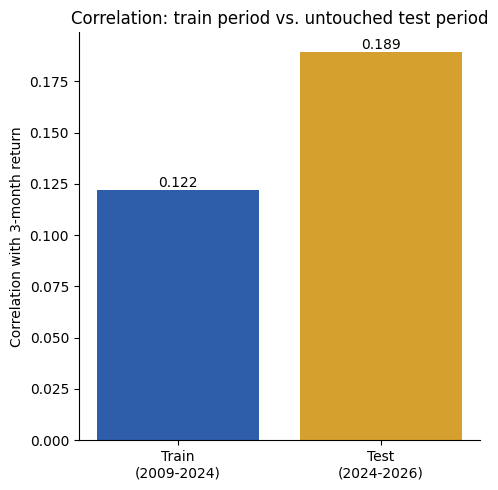

Train: correlation=0.122, p=0.0116, n=427
Test:  correlation=0.189, p=0.0102, n=183


In [5]:
sorted_signal = signal.sort_values("filing_date")
split_point = int(len(sorted_signal) * 0.7)
train, test = sorted_signal.iloc[:split_point], sorted_signal.iloc[split_point:]

train_corr, train_p = stats.spearmanr(train["negative_density_change"], train["return_3m"])
test_corr, test_p = stats.spearmanr(test["negative_density_change"], test["return_3m"])

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(
    [f"Train\n({train['filing_date'].min().year}-{train['filing_date'].max().year})",
     f"Test\n({test['filing_date'].min().year}-{test['filing_date'].max().year})"],
    [train_corr, test_corr], color=["#2E5EAA", "#D6A02E"],
)
ax.set_ylabel("Correlation with 3-month return")
ax.set_title("Correlation: train period vs. untouched test period")
ax.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.show()

print(f"Train: correlation={train_corr:.3f}, p={train_p:.4f}, n={len(train)}")
print(f"Test:  correlation={test_corr:.3f}, p={test_p:.4f}, n={len(test)}")


## 5. Is this broad, or one sector's story?


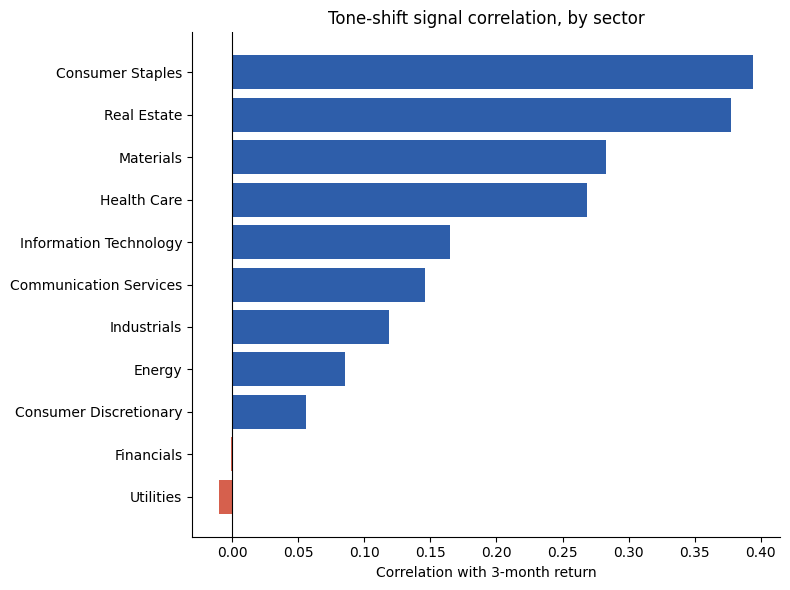

,sector,correlation,count
10,Utilities,-0.010296,36
4,Financials,-0.000986,79
1,Consumer Discretionary,0.055494,82
3,Energy,0.084980,23
6,Industrials,0.118652,99
0,Communication Services,0.145929,21
7,Information Technology,0.165122,89
5,Health Care,0.268469,70
8,Materials,0.283065,31
9,Real Estate,0.377486,40


In [6]:
sector_map = companies.rename(columns={"Symbol": "ticker"})[["ticker", "GICS Sector"]]
signal_sectors = signal.merge(sector_map, on="ticker", how="left")

sector_results = []
for sector, group in signal_sectors.groupby("GICS Sector"):
    if len(group) < 15:
        continue
    corr, p = stats.spearmanr(group["negative_density_change"], group["return_3m"])
    sector_results.append({"sector": sector, "correlation": corr, "count": len(group)})

sector_df = pd.DataFrame(sector_results).sort_values("correlation")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#D6604D" if c < 0 else "#2E5EAA" for c in sector_df["correlation"]]
ax.barh(sector_df["sector"], sector_df["correlation"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with 3-month return")
ax.set_title("Tone-shift signal correlation, by sector")
plt.tight_layout()
plt.show()

sector_df


## 6. Does it survive trading costs?

A simple long/short portfolio: buy the most-positive-tone-shift group,
short the most-negative group. Comparing the raw spread to a
cost-adjusted spread assuming a 0.20% round-trip cost per position.


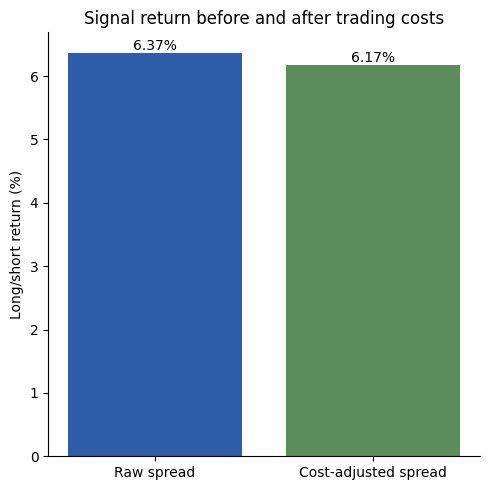

Raw spread: 6.37%
Cost-adjusted spread: 6.17%


In [7]:
ROUND_TRIP_COST = 0.0020

group_returns = signal.groupby("group", observed=True)["return_3m"].mean()
raw_spread = group_returns.iloc[-1] - group_returns.iloc[0]
cost_adjusted_spread = raw_spread - ROUND_TRIP_COST

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Raw spread", "Cost-adjusted spread"],
               [raw_spread * 100, cost_adjusted_spread * 100],
               color=["#2E5EAA", "#5B8C5A"])
ax.set_ylabel("Long/short return (%)")
ax.set_title("Signal return before and after trading costs")
ax.bar_label(bars, fmt="%.2f%%")
plt.tight_layout()
plt.show()

print(f"Raw spread: {raw_spread*100:.2f}%")
print(f"Cost-adjusted spread: {cost_adjusted_spread*100:.2f}%")


## Summary

- The signal shows a clear pattern at the extremes of the quintile sort,
  and holds for the median as well as the mean.
- It survives a momentum control, meaning it's not simply a disguised
  version of existing price trend.
- It holds up on a chronological out-of-sample test.
- It's broadly present across most sectors, with two plausible
  exceptions (Financials, Utilities).
- Trading costs, given the low turnover of this signal, don't
  meaningfully affect the conclusion.

See `FilingSignal_writeup.md` for the full write-up, including
limitations and next steps.
